# Citi Bike data quality and daily-demand exploration

**Owner:** Tomislav Novosel. Implementation and initial explanations were prepared with AI assistance; see [the assistance record](../docs/AI_USE.md). Team review and subsequent contributions should be recorded as work continues.

**Task 9:** determine whether the assembled data can support daily-demand
analysis, identify anomalies, and describe the patterns without overstating
what they prove. Run notebook 00 first.

Quality controls cover all downloaded records, including the adjacent January
archive; these diagnostics are not target-year totals. Substantive plots and demand
summaries below use **January–September only**. October–December is left aside
as a candidate final test period, pending the evaluation decision in task 12.
Do not use this exploratory notebook to choose models from that later period.


## Load the audited table

We verify the saved daily-table fingerprint and reconcile its totals with the recorded input count before drawing conclusions.

In [1]:
from pathlib import Path
import json
import sys
import pandas as pd
ROOT = Path.cwd()
while not (ROOT / 'src/citibike.py').exists():
    if ROOT == ROOT.parent:
        raise RuntimeError('Open this notebook inside the repository folder.')
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
from citibike import acquire_and_audit, sha256_file
config = json.loads((ROOT / 'citibike/source_config.json').read_text())
pd.set_option('display.max_colwidth', 110)

audit = json.loads((ROOT / 'reports/citibike/audit.json').read_text())
daily_path = ROOT / 'data/processed/citibike_daily.csv'
assert sha256_file(daily_path) == audit['daily_sha256']
daily = pd.read_csv(daily_path, index_col='date', parse_dates=['date'])
assert daily.index.is_unique and daily.index.is_monotonic_increasing
assert int(daily['trips'].sum()) + audit['issues']['outside_selected_year'] == audit['rows']
expected = pd.date_range(f"{config['year']}-01-01", f"{config['year']}-12-31", name='date')
assert daily.index.equals(expected)
eda = daily.loc[:config['exploration_end']].copy()
eda['weekday'] = eda.index.dayofweek
eda['weekday_name'] = eda.index.day_name()
eda['month'] = eda.index.month
print(f"Whole-source coverage: {len(daily)} days; exploration: {len(eda)} days")

Whole-source coverage: 365 days; exploration: 273 days


## Missing values and their meaning

We count missing fields across every source row. Missing start times would
prevent date assignment and stop the accepted dataset. Missing station names,
station IDs or end coordinates do **not** prevent counting an observed ride
start. Dropping such rows would change the target into a count of only fully
documented station-to-station rides. We retain them for this daily-count task.

These columns would need different treatment if the team later chose station
forecasting or a trip-duration model.


In [2]:
missing = pd.DataFrame.from_dict(audit['missing_values'], orient='index', columns=['missing_rows'])
missing['missing_percent'] = 100 * missing['missing_rows'] / audit['rows']
display(missing.sort_values('missing_rows', ascending=False).round(3))

,missing_rows,missing_percent
end_station_id,105412,0.285
end_station_name,105412,0.285
end_lat,104792,0.283
end_lng,104792,0.283
start_lat,19358,0.052
start_station_id,19358,0.052
start_station_name,19358,0.052
start_lng,19358,0.052
ended_at,0,0.000
rideable_type,0,0.000


## Duplicates, timestamps and coverage

Ride ID is the record key. The audit converts validated hexadecimal IDs to
their exact 64-bit values and sorts them across the entire year. This detects
repeat IDs between chunks and between files, rather than checking each CSV
in isolation. No approximate hash or sampled duplicate check is used.

Timestamps in the selected source have no timezone offsets. Our explicit
assumption is that the printed clock labels describe New York local dates;
we do not convert them to UTC. On daylight-saving transitions a local day can
contain 23 or 25 hours. Ride counts are daily totals, not counts per 24 hours.
Ambiguous autumn clock labels are retained on their printed date. Printed
clock durations can be misleading around DST, so they are diagnostic flags.

The audit also checks all expected dates and flags impossible, zero, short
and very long clock durations. A present date cannot prove every ride was
published; these checks establish complete calendar coverage, not a census
of unrecorded trips or unmet demand.


In [3]:
display(pd.Series(audit['issues'], name='rows').to_frame())
print('Missing calendar dates:', audit['missing_dates'])
print('Distinct schemas:', len(audit['schema_variants']))
print('Sample of starts outside the selected year:')
display(pd.DataFrame(audit['outside_year_sample']))
for name, counts in audit['categories'].items():
    print(name, counts)

,rows
autumn_dst_ambiguous_clock_hour,2921
distinct_duplicated_ride_ids,0
duplicate_ride_id_extra_rows,0
end_outside_filename_month,0
missing_or_non_hex_ride_id,0
negative_clock_duration,324
outside_selected_year,1887951
over_24_hour_clock_duration,27247
spring_dst_nonexistent_clock_hour,0
start_outside_filename_month,6888


Missing calendar dates: []
Distinct schemas: 1
Sample of starts outside the selected year:


,ride_id,started_at,ended_at
0,B11E5CDEA2E03294,2022-12-31 02:17:49.509,2023-01-01 03:17:43.084
1,8F78B584EE02383E,2022-12-31 04:37:33.529,2023-01-01 05:37:27.629
2,037903947BA15610,2022-12-31 13:52:06.979,2023-01-01 14:51:45.690
3,06A2C642DAE2539E,2022-12-31 19:13:08.712,2023-01-01 02:20:04.149
4,26FE7636069836C2,2022-12-31 23:41:51.908,2023-01-01 00:20:56.472
5,23B866A4088C3175,2022-12-31 23:25:12.498,2023-01-01 01:30:36.077
6,96117D4455FE4E6D,2022-12-31 23:51:25.629,2023-01-01 00:01:45.390
7,3587D391C1A7FD52,2022-12-31 23:45:10.050,2023-01-01 00:23:19.481
8,1CA0FB237D9A0196,2022-12-31 23:35:06.385,2023-01-01 00:16:04.921
9,158B009A7EA2C8EB,2022-12-31 23:34:37.916,2023-01-01 00:16:42.576


rideable_type {'classic_bike': 18174721, 'electric_bike': 18820350}
member_casual {'casual': 6801444, 'member': 30193627}


## Daily volume and monthly changes

Compare daily counts with a trailing seven-day average to see both individual
days and the slower change in volume. This average is a **descriptive plot**
that includes the current day; a forecast feature would need to be shifted
back first. Monthly averages use rides per day, so a longer month does not
automatically appear busier.


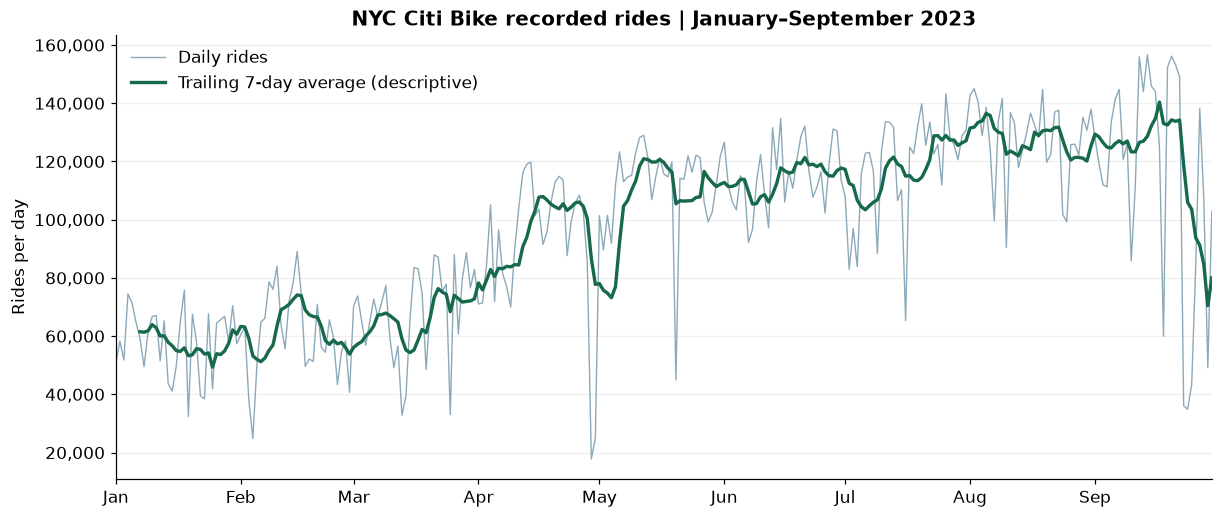

,days,total,mean_per_day
month,,,
1,31,1795329,57913.8
2,28,1696101,60575.0
3,31,2119314,68365.0
4,30,2749360,91645.3
5,31,3453576,111405.7
6,30,3451869,115062.3
7,31,3659372,118044.3
8,31,3964206,127877.6
9,30,3471658,115721.9


In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import StrMethodFormatter
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.titleweight': 'bold'})
FIGURES = ROOT / 'citibike/figures'
FIGURES.mkdir(parents=True, exist_ok=True)
fig, ax = plt.subplots(figsize=(11, 4.6), layout='constrained')
ax.plot(eda.index, eda['trips'], color='#8ba9b9', linewidth=0.9, label='Daily rides')
ax.plot(eda.index, eda['trips'].rolling(7).mean(), color='#17694c', linewidth=2.2,
        label='Trailing 7-day average (descriptive)')
ax.set(title='NYC Citi Bike recorded rides | January–September 2023', ylabel='Rides per day')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.set_xlim(eda.index.min(), eda.index.max())
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.grid(axis='y', alpha=0.2)
ax.legend(frameon=False, loc='upper left')
fig.savefig(FIGURES / 'daily_demand.png', dpi=150)
plt.show()
monthly = eda.groupby('month')['trips'].agg(days='size', total='sum', mean_per_day='mean')
display(monthly.round(1))

## Weekday patterns

Box plots show the spread: each box covers the middle 50% of observed days,
and its horizontal line marks the median. A weekday association can be
confounded by seasonal changes, holidays and serial dependence. This is
descriptive evidence to guide task 10, not a significance test or proof of
forecast accuracy.


,name,days,mean,median,std
weekday,,,,,
0,Monday,39,90331.3,97169.0,28213.4
1,Tuesday,39,101053.5,105667.0,32215.1
2,Wednesday,39,107029.1,115683.0,30848.1
3,Thursday,39,104289.9,107534.0,30855.4
4,Friday,39,99119.0,107756.0,29736.8
5,Saturday,39,90210.4,106001.0,37584.0
6,Sunday,39,83884.5,87659.0,31272.5


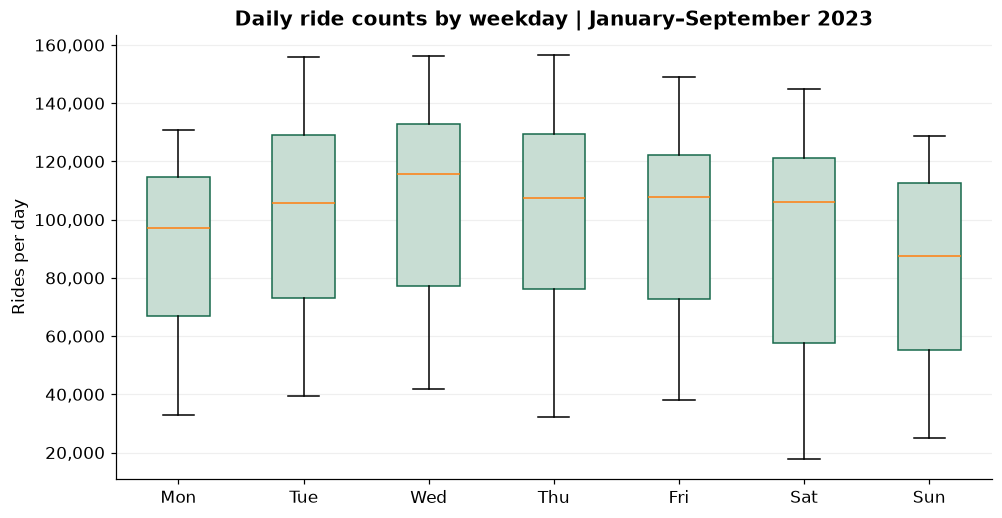

In [5]:
weekday = eda.groupby('weekday')['trips'].agg(days='size', mean='mean', median='median', std='std')
weekday['name'] = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
display(weekday[['name', 'days', 'mean', 'median', 'std']].round(1))
fig, ax = plt.subplots(figsize=(9, 4.6), layout='constrained')
groups = [eda.loc[eda['weekday'].eq(day), 'trips'].to_numpy() for day in range(7)]
boxes = ax.boxplot(groups, tick_labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], patch_artist=True)
for patch in boxes['boxes']:
    patch.set(facecolor='#c8ddd3', edgecolor='#17694c')
ax.set(title='Daily ride counts by weekday | January–September 2023', ylabel='Rides per day')
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.grid(axis='y', alpha=0.2)
fig.savefig(FIGURES / 'weekday_demand.png', dpi=150)
plt.show()

## Unusual days

We flag observations beyond 1.5 interquartile ranges as a descriptive screen.
This rule assumes neither a stable seasonal level nor an error in the data.
Consequently we keep the flagged days. A real holiday, disruption or weather
event may produce a legitimate low count; the plots alone do not establish
which explanation applies. Future models need to cope with such dates.


In [6]:
q1, q3 = eda['trips'].quantile([0.25, 0.75])
lower, upper = q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1)
flagged = eda.loc[eda['trips'].lt(lower) | eda['trips'].gt(upper), ['trips', 'weekday_name']]
print(f'IQR screen: {len(flagged)} flagged days; bounds {lower:,.0f} to {upper:,.0f}')
print('Five lowest observed development dates:')
display(eda.nsmallest(5, 'trips')[['trips', 'weekday_name']])
print('Five highest observed development dates:')
display(eda.nlargest(5, 'trips')[['trips', 'weekday_name']])
display(eda['trips'].describe().to_frame().round(1))

IQR screen: 0 flagged days; bounds -14,848 to 205,140
Five lowest observed development dates:


,trips,weekday_name
date,,
2023-04-29,17757,Saturday
2023-02-04,24810,Saturday
2023-04-30,24850,Sunday
2023-01-19,32358,Thursday
2023-03-13,32823,Monday


Five highest observed development dates:


,trips,weekday_name
date,,
2023-09-14,156602,Thursday
2023-09-20,156146,Wednesday
2023-09-12,155945,Tuesday
2023-09-21,153216,Thursday
2023-09-19,152304,Tuesday


,trips
count,273.0
mean,96559.7
std,32282.4
min,17757.0
25%,67647.0
50%,103370.0
75%,122644.0
max,156602.0


## Dependence on recent history

Autocorrelation compares the series with itself shifted by a number of days.
Lag 7 is relevant to a same-weekday-last-week baseline. The raw correlations
below also contain the changing seasonal level, so they are not a formal
test of an independent weekly effect. No p-values or model-quality claims
are derived from this figure.


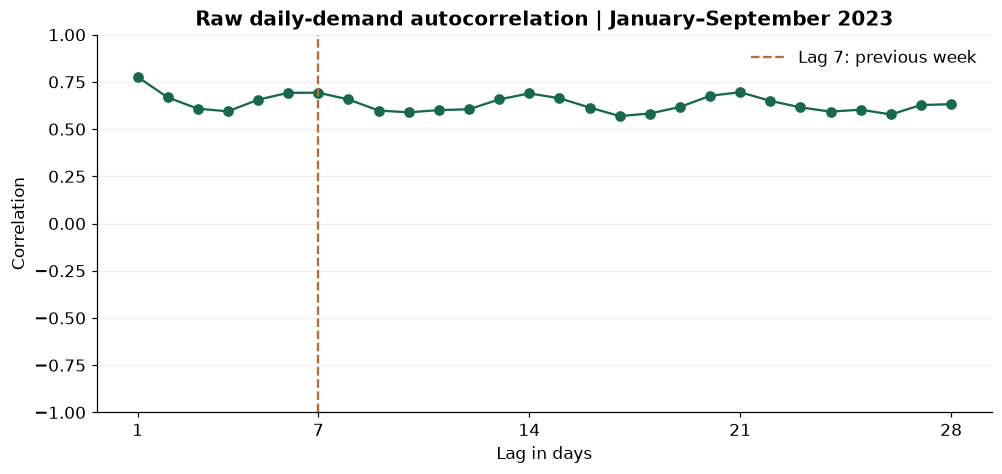

Lag-1 correlation: 0.776
Lag-7 correlation: 0.693


In [7]:
correlations = pd.Series({lag: eda['trips'].autocorr(lag=lag) for lag in range(1, 29)}, name='autocorrelation')
fig, ax = plt.subplots(figsize=(9, 4.2), layout='constrained')
ax.plot(correlations.index, correlations.values, marker='o', color='#17694c', linewidth=1.5)
ax.axvline(7, color='#b66d2f', linestyle='--', label='Lag 7: previous week')
ax.set(title='Raw daily-demand autocorrelation | January–September 2023',
       xlabel='Lag in days', ylabel='Correlation', ylim=(-1, 1), xticks=[1, 7, 14, 21, 28])
ax.grid(axis='y', alpha=0.2)
ax.legend(frameon=False)
fig.savefig(FIGURES / 'demand_autocorrelation.png', dpi=150)
plt.show()
print('Lag-1 correlation:', round(float(correlations.loc[1]), 3))
print('Lag-7 correlation:', round(float(correlations.loc[7]), 3))

## Record the findings

Store compact, machine-readable development summaries for the documentation. These contain no forecast results or final-test performance.

In [8]:
summary = {
    'exploration_start': eda.index.min().strftime('%Y-%m-%d'),
    'exploration_end': eda.index.max().strftime('%Y-%m-%d'), 'days': len(eda),
    'mean_daily_rides': float(eda['trips'].mean()),
    'lowest_date': eda['trips'].idxmin().strftime('%Y-%m-%d'),
    'lowest_count': int(eda['trips'].min()),
    'highest_date': eda['trips'].idxmax().strftime('%Y-%m-%d'),
    'highest_count': int(eda['trips'].max()),
    'lag_1_autocorrelation': float(correlations.loc[1]),
    'lag_7_autocorrelation': float(correlations.loc[7]),
    'iqr_flagged_days': len(flagged),
    'monthly': monthly.reset_index().to_dict(orient='records'),
    'weekday': weekday.reset_index().to_dict(orient='records'),
}
(ROOT / 'citibike/eda_summary.json').write_text(json.dumps(summary, indent=2) + '\n', encoding='utf-8')
print('Exploration summary saved. No model or hypothesis test has been run.')

Exploration summary saved. No model or hypothesis test has been run.


## Decisions and next tasks

- Select by actual start date, not the archive filename. Exclude starts outside
  the configured year and reconcile these exclusions with the original rows.
- Count each accepted recorded ride start once. The target is observed usage,
  not the number of people who wanted a bike but could not obtain one.
- Retain rows with missing station details or unusual durations for this
  counting target. Investigate them separately if the prediction scope changes.
- Do not silently zero-fill missing archive coverage or delete unusual days.
- Preserve local date semantics and record the timezone assumption; hourly
  or duration work would require a stronger DST policy.
- Keep January–September EDA separate from the candidate October–December
  holdout. The team still needs to lock chronological evaluation in task 12.
- Test the weekly-pattern hypothesis with a method that handles temporal
  dependence (task 10), then prepare forecast features and baselines (14, 16).

**Task 9 deliverables:** all-file quality evidence, reconciled daily counts,
missingness/duplicate/coverage decisions, three demand plots, unusual-date
examples and documented limitations. The team should review and explain them.
